In [ ]:
!pip install koreanize-matplotlib
!pip install shap

import openpyxl
import pickle
import pandas as pd
import collections
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 애드온 설치
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.3 MB/s eta 0:00:00


In [ ]:
import datetime
import openpyxl
import pickle
import pandas as pd
import collections
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#!pip install neuralforecast
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler # 변경됨
import joblib # 스케일러 저장용

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from tqdm.auto import tqdm # Colab에서 진행률 보기 좋은 라이브러리
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
!pip install pvlib
import pvlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 90.6 MB/s eta 0:00:00


In [ ]:
path = '/content/drive/MyDrive/범준학습/빅데이터/개인 발전량 예측 프로젝트(25)/Core/fromdb2_weighted.csv'
df_raw = pd.read_csv(path, encoding='cp949')

In [ ]:
# ==========================================
# 1. 하이퍼파라미터 및 기본 설정(태양광)
# ==========================================
SEQ_LEN = 336
PRED_LEN = 24
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-3

# [Transformer Backbone 파라미터]
PATCH_LEN = 24      # 패치 길이 (P)
STRIDE = 12       # 스트라이드 (S) - 겹치지 않게 이동 (Non-overlapping) 24 = non-overlap
#풍력은 24, Solar는 12 해볼예정
EMBED_DIM = 4       # 범주형 변수 임베딩 (기존 유지)
D_MODEL = 256      # 트랜스포머 내부 차원 (Latent Dimension) / 기존 128
#solar는 512도 해봐, wind = 256
NUM_HEADS = 4       # 멀티헤드 어텐션 개수  /  기존에는 4였음
NUM_LAYERS = 3      # 인코더 레이어 깊이 (보통 3~6 정도) / 기존 3이였음
D_FF = 1024         # FeedForward Layer 차원 (보통 D_MODEL * 2 or 4) / 기존 256
#solar는 2048, wind -= 1024
DROPOUT = 0.3      # 일반화 성능을 위해 드롭아웃 약간 상향 /  기존 0.3
# 풍력은 0.4 solar는 0.3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

In [ ]:
# 시간 파생 변수 생성
df['Hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['Year_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['Year_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

In [ ]:
# 당일 주간 누적 강수량 (모든 행에 broadcast)
daily_rain = df.groupby(df.index.date)['rainfall'].transform(
    lambda x: x.between_time('06:00', '20:00').sum()
)

df['solar_damping'] = np.exp(-0.163 * daily_rain.clip(upper=10))

In [ ]:
# 제주 표선면 좌표
lat, lon = 33.3284, 126.8366

# timestamp 인덱스를 timezone-aware로 변환
times = df.index.tz_localize('Asia/Seoul')

# Solar Elevation
solar_pos = pvlib.solarposition.get_solarposition(times, lat, lon)
df['Solar_Elevation'] = solar_pos['elevation'].values

# Extra Radiation
dni_extra = pvlib.irradiance.get_extra_radiation(times).values
df['Extra_Radiation'] = dni_extra * np.sin(np.radians(df['Solar_Elevation']))
df['Extra_Radiation'] = df['Extra_Radiation'].clip(lower=0)
df['Extra_Radiation'] = df['Extra_Radiation'] * 0.0036

# Solar Elevation Scaled (0~1)
min_el = df['Solar_Elevation'].min()
max_el = df['Solar_Elevation'].max()
df['Solar_Elevation_scaled'] = (df['Solar_Elevation'] - min_el) / (max_el - min_el)

df['Clearness_Index'] = df['solar_rad'] / (df['Extra_Radiation'] + 1e-5)

# 이론적 한계를 넘어가는 이상치(1.0 초과)는 1.0으로 클리핑, 음수 방지
df['Clearness_Index'] = df['Clearness_Index'].clip(lower=0.0, upper=1.0)
# 임시 컬럼 제거
#df = df.drop(columns=['Solar_Elevation'])

print(f"✅ Extra_Radiation 범위: {df['Extra_Radiation'].min():.2f} ~ {df['Extra_Radiation'].max():.2f}")
print(f"✅ Solar_Elevation_scaled 범위: {df['Solar_Elevation_scaled'].min():.4f} ~ {df['Solar_Elevation_scaled'].max():.4f}")
print(f"✅ Clearness_Index 범위: {df['Clearness_Index'].min():.4f} ~ {df['Clearness_Index'].max():.4f}")

✅ Extra_Radiation 범위: 0.00 ~ 4.66
✅ Solar_Elevation_scaled 범위: 0.0000 ~ 1.0000
✅ Clearness_Index 범위: 0.0000 ~ 1.0000


In [ ]:
# 임시보간
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].interpolate(limit=3)

In [ ]:
# ==========================================
# 2. 데이터 분할 및 스케일링 (가상의 df가 있다고 가정)
# ==========================================

# 시간순 분할 (사용자 지정 기준)
train_df = df.loc['2020-01-01':'2025-03-01'].copy()
val_df = df.loc['2025-03-02':'2026-03-01'].copy()
test_df = df.loc['2026-01-02': '2026-03-23'].copy()

# 사용할 모든 피처
features = [
    #'temp_c', 'wind_spd', 'humidity', 'rainfall',
    'solar_rad', 'total_cloud', 'midlow_cloud',
    'solar_damping',
    #'wd_sin', 'wd_cos',
    'Hour_sin', 'Hour_cos',
    #'Year_sin', 'Year_cos', #'Extra_Radiation',
    #'Solar_Elevation_scaled',
    'Solar_Utilization'
]

# 미래 예보로 사용할 피처 (Target인 Utilization 2개 제외하여 데이터 누수 방지)
future_features = [col for col in features if 'Utilization' not in col]
future_cov_idx = [features.index(col) for col in future_features]
target_idx = features.index('Solar_Utilization')

# 스케일링 (Utilization은 0~1이므로 스케일링에서 제외)
scale_cols = future_features
scaler_solar = MinMaxScaler()
#scaler_solar = RobustScaler()

train_df[scale_cols] = scaler_solar.fit_transform(train_df[scale_cols])
val_df[scale_cols] = scaler_solar.transform(val_df[scale_cols])
test_df[scale_cols] = scaler_solar.transform(test_df[scale_cols])


In [ ]:
df['solar_damping'].isnull().sum()

np.int64(0)

In [ ]:
# ==========================================
# 3. Dataset 수정 (past_y 추가)
# ==========================================
class PatchTSTDataset(Dataset):
    def __init__(self, data_array, seq_len, pred_len, future_idx, target_idx):
        self.data = data_array
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.future_idx = future_idx # 날씨/시간 피처들
        self.target_idx = target_idx # Solar_Utilization

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # 과거 구간
        past_data = self.data[idx : idx + self.seq_len]
        past_numeric = past_data[:, self.future_idx] # (SEQ_LEN, 16)
        past_y = past_data[:, self.target_idx : self.target_idx+1] # (SEQ_LEN, 1)

        # 미래 구간 (예보 정보)
        future_data = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        future_numeric = future_data[:, self.future_idx] # (PRED_LEN, 16)
        future_y = future_data[:, self.target_idx] # (PRED_LEN,)

        return {
            'past_numeric': torch.FloatTensor(past_numeric),
            'past_y': torch.FloatTensor(past_y),
            'future_numeric': torch.FloatTensor(future_numeric),
            'future_y': torch.FloatTensor(future_y)
        }

# ==========================================

class InstanceNormalization(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm', mean=None, std=None):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            return (x - self.mean) / self.std * self.affine + self.bias
        elif mode == 'denorm':
            return (x - self.bias) / self.affine * std + mean
        return x


In [ ]:
# ==========================================
# Weather Attetion Model
# ==========================================

class Patch_Weather_Attention(nn.Module):
    """
    통합 Weather Attention (query_dim / key_dim 분리)
    Solar: patch_len=24, pred_len=24 → query_dim == key_dim
    """
    def __init__(self, query_dim, key_dim, hidden_dim):
        super().__init__()
        self.W_Q = nn.Sequential(nn.Linear(query_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.W_K = nn.Sequential(nn.Linear(key_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim))
        self.scale_factor = 1.0 / (hidden_dim ** 0.5)

    def forward(self, future_weather_patch, past_weather_patches, transformer_output):
        Q = self.W_Q(future_weather_patch).unsqueeze(1)
        K = self.W_K(past_weather_patches)
        score = torch.bmm(Q, K.transpose(1, 2)) * self.scale_factor
        attn_weights = F.softmax(score, dim=-1)
        context = torch.bmm(attn_weights, transformer_output)
        return context.squeeze(1), attn_weights

class PatchTST_Weather_Model(nn.Module):
    def __init__(self, num_features,
                 seq_len=336, pred_len=24, patch_len=24,
                 stride=12,
                 d_model=128,
                 num_heads=4,
                 num_layers=2,
                 d_ff=256, dropout=0.2):
        super(PatchTST_Weather_Model, self).__init__()

        self.patch_len = patch_len
        self.stride = stride
        self.d_model = d_model
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_patches = (self.seq_len - self.patch_len) // self.stride + 1

        self.inst_norm = InstanceNormalization(num_features)

        patch_input_dim = self.patch_len * num_features
        self.patch_embedding = nn.Linear(patch_input_dim, self.d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches, self.d_model))
        self.dropout = nn.Dropout(DROPOUT)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, nhead=NUM_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)

        self.num_weather_feats = num_features - 1
        future_weather_flat_dim = self.pred_len * self.num_weather_feats
        weather_patch_dim = self.patch_len * self.num_weather_feats

        # 통합 Attention: Solar는 24*15 == 24*15 (동일)
        self.weather_attn = Patch_Weather_Attention(
            query_dim=future_weather_flat_dim,
            key_dim=weather_patch_dim,
            hidden_dim=self.d_model
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.d_model + future_weather_flat_dim, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(DROPOUT),
            nn.Linear(256, self.pred_len)
        )

    def forward(self, batch):
        p_num = batch['past_numeric'].to(DEVICE)
        p_y = batch['past_y'].to(DEVICE)
        f_num = batch['future_numeric'].to(DEVICE)
        B = p_num.shape[0]

        x_past = torch.cat([p_num, p_y], dim=-1)
        x_past = self.inst_norm(x_past, mode='norm')

        x_patches = x_past.unfold(dimension=1, size=self.patch_len, step=self.stride)
        x_patches = x_patches.permute(0, 1, 3, 2).reshape(B, self.num_patches, -1)

        enc_out = self.patch_embedding(x_patches) + self.pos_embedding
        enc_out = self.transformer_encoder(self.dropout(enc_out))

        future_weather_flat = f_num.reshape(B, -1)

        x_past_weather = x_past[..., :-1]
        w_patches = x_past_weather.unfold(1, self.patch_len, self.stride)
        w_patches = w_patches.permute(0, 1, 3, 2).reshape(B, self.num_patches, -1)

        context, _ = self.weather_attn(future_weather_flat, w_patches, enc_out)

        total_input = torch.cat([context, future_weather_flat], dim=1)
        prediction = self.regressor(total_input)

        return prediction

In [ ]:
# @title
class DaylightMSELoss(nn.Module):
    def __init__(self, threshold=0.01):
        super(DaylightMSELoss, self).__init__()
        self.threshold = threshold
        # reduction='none'으로 설정하여 평균을 내지 않고 개별 오차 텐서를 그대로 반환받음
        #self.mae_loss = nn.L1Loss(reduction='none'ㅁ)
        self.mse_loss = nn.MSELoss(reduction='none')

    def forward(self, pred, target):
        # 마스크 생성: 실제 발전량이 있거나 OR 모델이 임계치 이상으로 잘못 예측한 경우
        mask = (target > 0) | (pred > self.threshold)

        # 만약 배치 내에 계산할 대상(낮 시간)이 아예 없다면 0 반환 (에러 방지)
        if mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True).to(pred.device)

        # 개별 오차 계산
        loss_all = self.mse_loss(pred, target)

        # 마스크가 True인 부분만 추출하여 평균(MAE) 계산
        daylight_loss = loss_all[mask].mean()

        return daylight_loss

In [ ]:
class DaylightWeightedMSELoss(nn.Module):
    def __init__(self, threshold=0.01, low_util_cutoff=0.25,
                 high_weight=3.0, overpredict_penalty=1.5):
        super().__init__()
        self.threshold = threshold
        self.low_util_cutoff = low_util_cutoff
        self.high_weight = high_weight
        self.overpredict_penalty = overpredict_penalty
        self.mse_loss = nn.MSELoss(reduction='none')

    def forward(self, pred, target):
        mask = (target > 0) | (pred > self.threshold)

        if mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True).to(pred.device)

        loss_all = self.mse_loss(pred, target)

        # 1) 흐린 날 가중치
        weights = torch.ones_like(target)
        cloudy = (target > self.threshold) & (target <= self.low_util_cutoff)
        weights[cloudy] = self.high_weight

        # 2) 과대예측 추가 페널티 (흐린 날 + pred > target)
        overpredict = cloudy & (pred > target)
        weights[overpredict] = self.high_weight * self.overpredict_penalty

        weighted_loss = (loss_all * weights)[mask].mean()
        return weighted_loss

In [ ]:
# 1. 모델 및 학습 도구 초기화
input_size = len(future_features) + 1
model = PatchTST_Weather_Model(
    num_features=input_size,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

#model = PatchTST_Weather_Model(num_features=len(features)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
#criterion = nn.L1Loss() # MAE
#criterion = nn.HuberLoss() # MAE
#criterion = DaylightMSELoss(threshold=0.01)
#criterion = DaylightWeightedMSELoss(threshold=0.01, low_util_cutoff=0.3, high_weight=5.5)
criterion = DaylightWeightedMSELoss(threshold=0.01, low_util_cutoff=0.25, high_weight=3.0, overpredict_penalty=1.5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 2. Dataset 및 Loader 생성
train_ds = PatchTSTDataset(train_df[features].values, SEQ_LEN, PRED_LEN, future_cov_idx, target_idx)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_ds = PatchTSTDataset(val_df[features].values, SEQ_LEN, PRED_LEN, future_cov_idx, target_idx)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# 3. Training Loop (사용자님 기존 루프와 동일한 로직)
best_val_loss = float('inf')
patience = 15  # 성능 개선이 없을 때 기다릴 에폭 수
patience_counter = 0
best_val_loss = float('inf')


/tmp/ipykernel_3165/575252752.py:67: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


In [ ]:
print(f"🚀 {DEVICE} 장치에서 학습을 시작합니다...")

for epoch in range(1, EPOCHS + 1):
    # --- [1] Training Phase ---
    model.train()
    train_loss = 0.0

    # tqdm 진행바 설정
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for batch in train_pbar:
        optimizer.zero_grad()

        output = model(batch)
        target = batch['future_y'].to(DEVICE)

        loss = criterion(output, target)
        loss.backward()

        # Gradient Clipping (학습 안정성 확보)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

        # 실시간 손실 업데이트
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)

    # --- [2] Validation Phase ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            output = model(batch)
            target = batch['future_y'].to(DEVICE)

            loss = criterion(output, target)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # --- [3] Scheduler & Logging ---
    # 검증 손실을 기준으로 학습률 조정
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch:03d}] | Train MAE: {avg_train_loss:.4f} | Val MAE: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    # --- [4] Early Stopping & Model Save ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # 가장 좋은 모델 가중치 저장
        torch.save(model.state_dict(), 'best_patchtst_solar_model_minmax.pth')
        print(f"✨ Best Model Saved! (Val Loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"🛑 조기 종료! {patience} 에폭 동안 개선이 없었습니다.")
        break

print("-" * 30)
print(f"✅ 학습 완료! 최적의 Validation MAE: {best_val_loss:.4f}")
joblib.dump(scaler_solar, 'robust_scaler_solar_minmax.pkl')
#마지막 ✅ 학습 완료! 최적의 Validation MAE: 0.0103
#✅ 학습 완료! 최적의 Validation MAE: 0.0102 < - 강우피처 2개 추가
# ✨ Best Model Saved! (Val Loss: 0.0105) < - 강우피처 3개추가, solar_elevation 제거

🚀 cuda 장치에서 학습을 시작합니다...


Epoch 1/100 [Train]:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch [001] | Train MAE: 0.0265 | Val MAE: 0.0355 | LR: 0.001000
✨ Best Model Saved! (Val Loss: 0.0355)


Epoch 2/100 [Train]:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch [002] | Train MAE: 0.0149 | Val MAE: 0.0315 | LR: 0.001000
✨ Best Model Saved! (Val Loss: 0.0315)


...

Epoch 34/100 [Train]:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch [034] | Train MAE: 0.0057 | Val MAE: 0.0239 | LR: 0.000250


Epoch 35/100 [Train]:   0%|          | 0/351 [00:00<?, ?it/s]

Epoch [035] | Train MAE: 0.0056 | Val MAE: 0.0236 | LR: 0.000250
🛑 조기 종료! 15 에폭 동안 개선이 없었습니다.
------------------------------
✅ 학습 완료! 최적의 Validation MAE: 0.0202


['robust_scaler_solar_minmax.pkl']

/tmp/ipykernel_3165/575252752.py:67: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


✅ /content/best_patchtst_solar_model_minmax.pth 로드 완료!


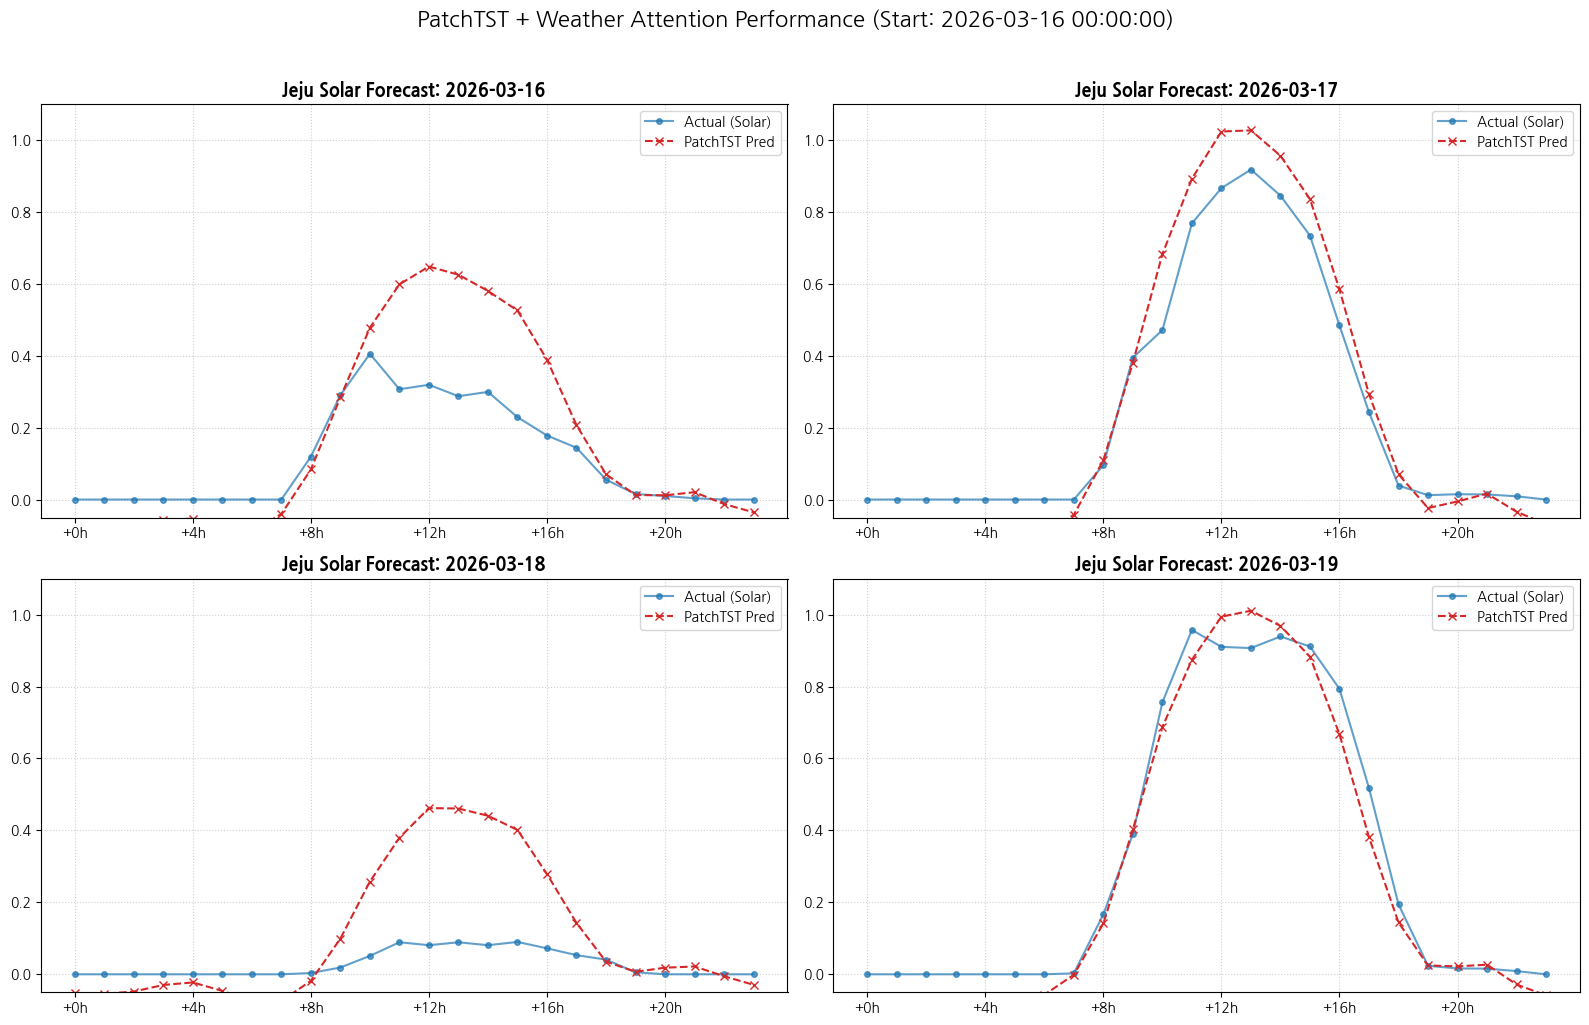

In [ ]:
# 1. 모델 인스턴스 생성 (15개 기상피처 + 1개 타겟 = 16)
input_size = len(future_features) + 1

best_model = PatchTST_Weather_Model(
    num_features=input_size,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

# 2. 저장된 가중치 불러오기 (파일명은 본인이 저장한 이름으로 수정)
# 에러 방지를 위해 map_location 설정을 추가했습니다.
#/content/best_solar_dnn_model_origin.pth
weights_path = '/content/best_patchtst_solar_model_minmax.pth'
best_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
best_model.eval()

test_ds = PatchTSTDataset(
    test_df[features].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx,
    target_idx
)

print(f"✅ {weights_path} 로드 완료!")

def plot_patchtst_forecast(start_date_str):
    try:
        # 테스트 데이터에서 시작 위치 찾기
        target_start_loc = test_df.index.get_loc(start_date_str)
    except KeyError:
        print(f"❌ 오류: '{start_date_str}'는 테스트 데이터 기간에 없습니다.")
        return

    # test_dataset은 PatchTSTDataset의 인스턴스여야 합니다.
    base_idx = target_start_loc - SEQ_LEN
    if base_idx < 0 or base_idx + 72 >= len(test_ds):
        print("❌ 오류: 시퀀스 데이터가 부족하여 그래프를 그릴 수 없습니다.")
        return

    indices = [base_idx, base_idx + 24, base_idx + 48, base_idx + 72]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Dataset에서 샘플 가져오기 (딕셔너리 형태)
            sample = test_ds[idx]

            # 모든 텐서에 배치 차원(1) 추가 및 장치 이동
            # v.unsqueeze(0) -> (Batch=1, Seq, Feat)
            batch_sample = {k: v.unsqueeze(0).to(DEVICE) for k, v in sample.items()}

            # 모델 추론
            # PatchTST 모델은 내부에서 batch를 통째로 받아 처리합니다.
            pred_y = best_model(batch_sample) # (1, 24)

            # 데이터 변환 (Numpy)
            actual = sample['future_y'].numpy()            # (24,)
            predicted = pred_y.squeeze().cpu().numpy()     # (24,)

            # 그래프 그리기
            # 실제 예측 대상 날짜 계산
            current_date = test_df.index[target_start_loc + (i * 24)].strftime('%Y-%m-%d')

            ax = axes[i]
            ax.plot(actual, label='Actual (Solar)', marker='o', markersize=4, color='#1f77b4', alpha=0.7)
            ax.plot(predicted, label='PatchTST Pred', marker='x', linestyle='--', color='#d62728', linewidth=1.5)

            ax.set_title(f"Jeju Solar Forecast: {current_date}", fontsize=13, fontweight='bold')
            ax.set_ylim(-0.05, 1.1) # 0~1 범위를 약간 넘는지 확인하기 위해 1.1까지 설정
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels([f"+{h}h" for h in range(0, 24, 4)])
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"PatchTST + Weather Attention Performance (Start: {start_date_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 실행 예시
#plot_patchtst_forecast('2026-01-15 00:00:00')
#plot_patchtst_forecast('2026-02-15 00:00:00')
plot_patchtst_forecast('2026-03-16 00:00:00')

Base MSE Loss: 0.0115
Feature: solar_rad            | Shuffled Loss: 0.0360 | Importance: 0.0246
Feature: total_cloud          | Shuffled Loss: 0.0153 | Importance: 0.0038
Feature: midlow_cloud         | Shuffled Loss: 0.0139 | Importance: 0.0024
Feature: solar_damping        | Shuffled Loss: 0.0128 | Importance: 0.0013
Feature: Hour_sin             | Shuffled Loss: 0.0173 | Importance: 0.0058
Feature: Hour_cos             | Shuffled Loss: 0.0160 | Importance: 0.0046


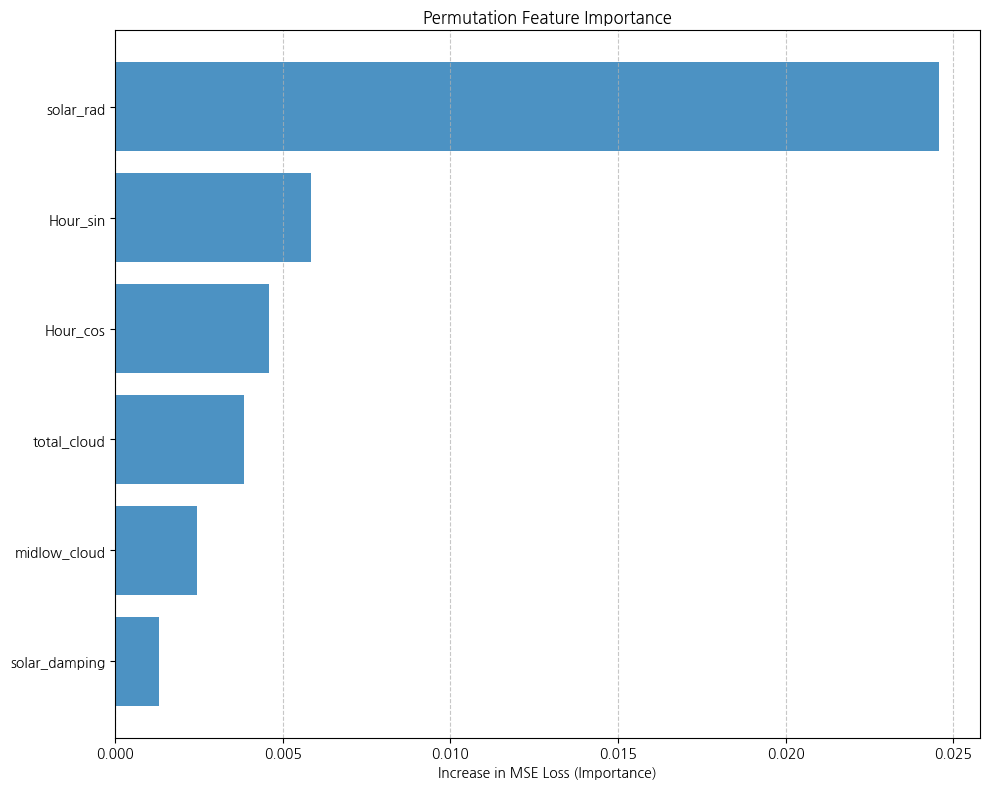

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def calculate_permutation_importance(model, dataset, feature_names, device, batch_size=64):
    model.eval()
    criterion = nn.MSELoss()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # 1. 원본 데이터의 Base Loss 계산
    base_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch_to_device = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch_to_device)
            loss = criterion(pred, batch_to_device['future_y'])
            base_loss += loss.item() * batch['future_y'].size(0)
    base_loss /= len(dataset)
    print(f"Base MSE Loss: {base_loss:.4f}")

    importances = {}

    # 2. 피처별로 순서를 섞어가며 Loss 변화 측정
    for c_idx, col_name in enumerate(feature_names):
        shuffled_loss = 0.0
        with torch.no_grad():
            for batch in loader:
                # 데이터 원본 보존을 위해 복사본 생성
                p_num = batch['past_numeric'].clone()
                f_num = batch['future_numeric'].clone()

                # 배치 차원(Batch Dimension)을 기준으로 랜덤 인덱스 생성
                rand_idx = torch.randperm(p_num.size(0))

                # 해당 피처(c_idx)의 데이터만 랜덤하게 섞음
                p_num[:, :, c_idx] = p_num[rand_idx, :, c_idx]
                f_num[:, :, c_idx] = f_num[rand_idx, :, c_idx]

                shuffled_batch = {
                    'past_numeric': p_num.to(device),
                    'past_y': batch['past_y'].to(device),
                    'future_numeric': f_num.to(device),
                    'future_y': batch['future_y'].to(device)
                }

                pred = model(shuffled_batch)
                loss = criterion(pred, shuffled_batch['future_y'])
                shuffled_loss += loss.item() * p_num.size(0)

        shuffled_loss /= len(dataset)

        # 중요도 = 섞었을 때의 Loss - 원본 Loss (값이 클수록 중요한 피처)
        importance_score = shuffled_loss - base_loss
        importances[col_name] = importance_score
        print(f"Feature: {col_name:<20} | Shuffled Loss: {shuffled_loss:.4f} | Importance: {importance_score:.4f}")

    # 3. 중요도 순으로 정렬
    sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=False)

    # 4. 시각화
    names = [item[0] for item in sorted_importances]
    scores = [item[1] for item in sorted_importances]

    plt.figure(figsize=(10, 8))
    plt.barh(names, scores, color='#1f77b4', alpha=0.8)
    plt.xlabel('Increase in MSE Loss (Importance)')
    plt.title('Permutation Feature Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return sorted_importances

# 실행 예시 (future_features 리스트가 정의되어 있다고 가정)
imp_results = calculate_permutation_importance(best_model, test_ds, future_features, DEVICE)

Filtered Base MSE Loss (Max < 0.7): 0.0085 (Valid Samples: 1016)
Feature: solar_rad            | Shuffled Loss: 0.0218 | Importance: 0.0133
Feature: total_cloud          | Shuffled Loss: 0.0155 | Importance: 0.0070
Feature: midlow_cloud         | Shuffled Loss: 0.0135 | Importance: 0.0051
Feature: solar_damping        | Shuffled Loss: 0.0119 | Importance: 0.0034
Feature: Hour_sin             | Shuffled Loss: 0.0063 | Importance: -0.0022
Feature: Hour_cos             | Shuffled Loss: 0.0064 | Importance: -0.0021


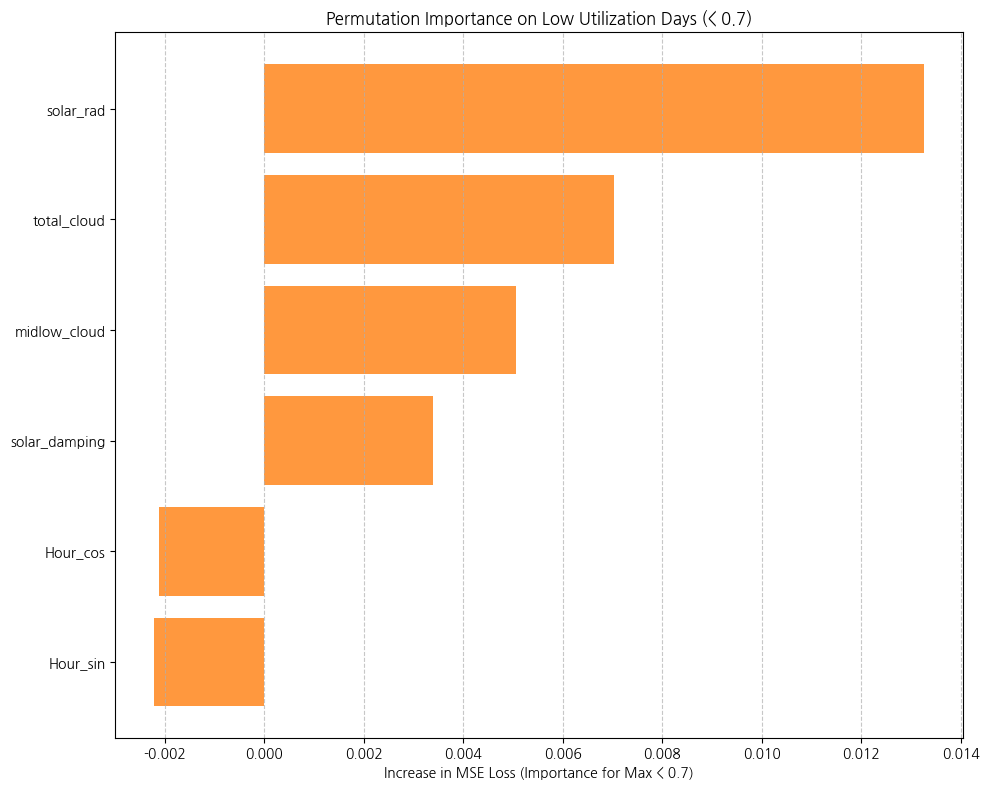

In [ ]:
def calculate_conditional_permutation_importance(model, dataset, feature_names, device, batch_size=128, threshold=0.5):
    """
    최대 발전량(Target)이 특정 임계값(0.5) 미만인 악천후/흐린 날에 대해서만
    Permutation Feature Importance를 계산합니다.
    """
    model.eval()
    # Masking된 텐서의 Loss를 정확히 누적하기 위해 reduction='sum' 사용
    criterion = nn.MSELoss(reduction='sum')
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    total_valid_samples = 0
    base_loss_sum = 0.0

    # ---------------------------------------------------------
    # 1. 0.5 미만 구간의 Base Loss 및 유효 샘플 수 계산
    # ---------------------------------------------------------
    with torch.no_grad():
        for batch in loader:
            batch_to_device = {k: v.to(device) for k, v in batch.items()}
            true_y = batch_to_device['future_y']

            # 24시간 중 최대 발전량 계산
            if true_y.dim() == 3:
                max_vals = true_y.max(dim=1)[0].squeeze(-1)
            else:
                max_vals = true_y.max(dim=1)[0]

            # 조건 마스크 생성 (0.5 미만)
            mask = max_vals > threshold ## 임시로 threshold 이상으로 조정가능
            valid_count = mask.sum().item()

            if valid_count == 0:
                continue

            total_valid_samples += valid_count

            pred = model(batch_to_device)

            # 조건에 맞는 샘플만 Loss 누적 (MSE * N 을 위해 sum 사용)
            loss = criterion(pred[mask], true_y[mask])
            base_loss_sum += loss.item()

    if total_valid_samples == 0:
        print(f"조건(Max < {threshold})을 만족하는 데이터가 없습니다.")
        return []

    # 평균 Base Loss 계산
    base_loss = base_loss_sum / (total_valid_samples * dataset.pred_len) # MSE 단위 보정
    print(f"Filtered Base MSE Loss (Max < {threshold}): {base_loss:.4f} (Valid Samples: {total_valid_samples})")

    importances = {}

    # ---------------------------------------------------------
    # 2. 피처별 셔플 및 조건부 Loss 계산
    # ---------------------------------------------------------
    for c_idx, col_name in enumerate(feature_names):
        shuffled_loss_sum = 0.0

        with torch.no_grad():
            for batch in loader:
                true_y = batch['future_y'].to(device)

                # 24시간 중 최대 발전량 계산 및 마스크 생성
                if true_y.dim() == 3:
                    max_vals = true_y.max(dim=1)[0].squeeze(-1)
                else:
                    max_vals = true_y.max(dim=1)[0]
                mask = max_vals < threshold

                if mask.sum().item() == 0:
                    continue

                # 데이터 복사 및 셔플 (배치 전체에 대해 셔플 후 마스크 적용)
                p_num = batch['past_numeric'].clone()
                f_num = batch['future_numeric'].clone()

                rand_idx = torch.randperm(p_num.size(0))

                p_num[:, :, c_idx] = p_num[rand_idx, :, c_idx]
                f_num[:, :, c_idx] = f_num[rand_idx, :, c_idx]

                shuffled_batch = {
                    'past_numeric': p_num.to(device),
                    'past_y': batch['past_y'].to(device),
                    'future_numeric': f_num.to(device),
                    'future_y': true_y
                }

                pred = model(shuffled_batch)

                # 마스크된 타겟 구간에 대해서만 Loss 합산
                loss = criterion(pred[mask], true_y[mask])
                shuffled_loss_sum += loss.item()

        # 평균 Shuffled Loss 계산
        shuffled_loss = shuffled_loss_sum / (total_valid_samples * dataset.pred_len)

        # 중요도 = Shuffled Loss - Base Loss
        importance_score = shuffled_loss - base_loss
        importances[col_name] = importance_score
        print(f"Feature: {col_name:<20} | Shuffled Loss: {shuffled_loss:.4f} | Importance: {importance_score:.4f}")

    # ---------------------------------------------------------
    # 3. 중요도 정렬 및 시각화
    # ---------------------------------------------------------
    sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=False)

    names = [item[0] for item in sorted_importances]
    scores = [item[1] for item in sorted_importances]

    plt.figure(figsize=(10, 8))
    plt.barh(names, scores, color='#ff7f0e', alpha=0.8) # 주황색 톤으로 변경
    plt.xlabel(f'Increase in MSE Loss (Importance for Max < {threshold})')
    plt.title(f'Permutation Importance on Low Utilization Days (< {threshold})')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return sorted_importances

# 실행 예시
# future_features 리스트가 정의되어 있다고 가정합니다.
low_util_importances = calculate_conditional_permutation_importance(
    best_model, test_ds, future_features, DEVICE, batch_size=BATCH_SIZE, threshold=0.7
)
#Filtered Base MSE Loss (Max < 0.5): 0.0245 (Valid Samples: 451) <- Solar_Elevation_scaled 그대로, rain_ema_3h, rain_impact 넣었을 때

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def evaluate_by_max_utilization(model, dataset, device, batch_size=128, threshold=0.5):
    """
    최대 발전량(Utilization)이 특정 임계값(0.5) 미만인 날과 이상인 날을 구분하여
    각각의 MSE Loss를 계산하고 비교합니다.
    """
    model.eval()
    criterion = nn.MSELoss()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    low_util_losses = []   # 최댓값 0.5 미만 (흐린 날, 비 온 날)
    high_util_losses = []  # 최댓값 0.5 이상 (맑은 날, 정상 가동)

    with torch.no_grad():
        for batch in loader:
            batch_to_device = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch_to_device)
            true_y = batch_to_device['future_y']

            # 1. 24시간(PRED_LEN) 동안의 최대 발전량 계산
            # true_y의 형태가 [batch_size, pred_len, features] 또는 [batch_size, pred_len]일 수 있음
            if true_y.dim() == 3:
                max_vals, _ = torch.max(true_y, dim=1)
                max_vals = max_vals.squeeze(-1) # 형태를 [batch_size]로 맞춤
            else:
                max_vals, _ = torch.max(true_y, dim=1) # 형태: [batch_size]

            # 2. 조건에 맞는 마스크(Mask) 생성
            low_mask = max_vals < threshold
            high_mask = max_vals >= threshold

            # 3. 0.5 미만인 데이터(Low Utilization) Loss 계산
            if low_mask.any():
                low_pred = pred[low_mask]
                low_true = true_y[low_mask]
                low_loss = criterion(low_pred, low_true).item()
                # 평균을 정확히 구하기 위해 샘플 개수를 함께 저장
                low_util_losses.append((low_loss, low_mask.sum().item()))

            # 4. 0.5 이상인 데이터(High Utilization) Loss 계산
            if high_mask.any():
                high_pred = pred[high_mask]
                high_true = true_y[high_mask]
                high_loss = criterion(high_pred, high_true).item()
                high_util_losses.append((high_loss, high_mask.sum().item()))

    # --- 가중 평균을 통한 최종 Loss 계산 ---
    def calculate_weighted_mean(loss_list):
        if not loss_list:
            return 0.0
        total_loss = sum(l * count for l, count in loss_list)
        total_count = sum(count for l, count in loss_list)
        return total_loss / total_count, total_count

    mean_low_loss, count_low = calculate_weighted_mean(low_util_losses)
    mean_high_loss, count_high = calculate_weighted_mean(high_util_losses)

    print(f"=== Utilization 최고점 기준 평가 결과 (Threshold: {threshold}) ===")
    print(f"1. 흐린 날 / 비 온 날 (Max < {threshold})")
    print(f"   - 샘플 윈도우 수: {count_low}개")
    print(f"   - MSE Loss: {mean_low_loss:.4f}")
    print("-" * 50)
    print(f"2. 맑은 날 / 정상 가동 (Max >= {threshold})")
    print(f"   - 샘플 윈도우 수: {count_high}개")
    print(f"   - MSE Loss: {mean_high_loss:.4f}")

    return mean_low_loss, mean_high_loss

# 실행 예시
# best_model과 test_ds가 준비된 상태에서 아래 함수를 호출합니다.
low_loss, high_loss = evaluate_by_max_utilization(best_model, test_ds, DEVICE, BATCH_SIZE, threshold=0.5)

=== Utilization 최고점 기준 평가 결과 (Threshold: 0.5) ===
1. 흐린 날 / 비 온 날 (Max < 0.5)
   - 샘플 윈도우 수: 451개
   - MSE Loss: 0.0245
--------------------------------------------------
2. 맑은 날 / 정상 가동 (Max >= 0.5)
   - 샘플 윈도우 수: 1134개
   - MSE Loss: 0.0079


In [ ]:
train_df_raw = df.loc['2020-01-01':'2024-09-30'].copy()
scaler_fresh = RobustScaler()
scaler_fresh.fit(train_df_raw[future_features])

print("Fresh scaler center:", scaler_fresh.center_[:5])
print("Fresh scaler scale:", scaler_fresh.scale_[:5])
print(df.loc['2026-03-16 00:00:00'][['temp_c', 'wind_spd', 'humidity']])

# ft_val_df에서 3월 16일 구간 직접 추출
target_start = '2026-03-02 00:00:00'  # 336시간 전
target_end = '2026-03-16 23:00:00'

sample_df = ft_val_df.loc[target_start:target_end]
print("sample length:", len(sample_df))

past_numeric = torch.FloatTensor(sample_df.iloc[:336][future_features].values).unsqueeze(0)
past_y = torch.FloatTensor(sample_df.iloc[:336][['Solar_Utilization']].values).unsqueeze(0)
future_numeric = torch.FloatTensor(sample_df.iloc[336:360][future_features].values).unsqueeze(0)

print("=== Colab 3/16 Debug ===")
print("past_numeric mean:", past_numeric.mean().item())
print("past_numeric std:", past_numeric.std().item())
print("past_y mean:", past_y.mean().item())
print("future_numeric mean:", future_numeric.mean().item())
print("past_numeric[0,0,:5]:", past_numeric[0, 0, :5].tolist())
print("future_numeric[0,0,:5]:", future_numeric[0, 0, :5].tolist())
# Colab
print("Colab features:", future_features)
print("Colab scaler center:", scaler_solar.center_[:5])
print("Colab scaler scale:", scaler_solar.scale_[:5])

Fresh scaler center: [0.00000000e+00 7.00000000e+00 3.00000000e+00 1.13686838e-14
 0.00000000e+00]
Fresh scaler scale: [5.40000000e-01 8.00000000e+00 7.00000000e+00 1.05667118e-04
 1.00000000e+00]
temp_c       8.4
wind_spd     1.5
humidity    63.0
Name: 2026-03-16 00:00:00, dtype: object


NameError: name 'ft_val_df' is not defined

In [ ]:
# ==========================================
# Solar Fine-tuning (24년 12월 이후 데이터)
# ==========================================

# 1. 기존 best 모델 로드
model_solar = PatchTST_Weather_Model(
    num_features=input_size,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)
model_solar.load_state_dict(torch.load('/content/best_patchtst_solar_model.pth', map_location=DEVICE))

# 2. 낮은 learning rate (기존의 1/10)
optimizer_ft = torch.optim.AdamW(model_solar.parameters(), lr=1e-4, weight_decay=1e-5)
criterion_solar = DaylightMSELoss(threshold=0.01)

# 3. 최근 데이터만 Dataset 구성
ft_train_df = df.loc['2024-12-01':'2025-12-31'].copy()
ft_val_df = df.loc['2026-01-01':].copy()

ft_train_df[future_features] = scaler_solar.transform(ft_train_df[future_features])
ft_val_df[future_features] = scaler_solar.transform(ft_val_df[future_features])

ft_train_ds = PatchTSTDataset(ft_train_df[features].values, SEQ_LEN, PRED_LEN, future_cov_idx, target_idx)
ft_val_ds = PatchTSTDataset(ft_val_df[features].values, SEQ_LEN, PRED_LEN, future_cov_idx, target_idx)

ft_train_loader = DataLoader(ft_train_ds, batch_size=64, shuffle=True, drop_last=True)
ft_val_loader = DataLoader(ft_val_ds, batch_size=64, shuffle=False)


/tmp/ipykernel_13968/2389722735.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


FileNotFoundError: [Errno 2] No such file or directory: '/content/best_patchtst_solar_model.pth'

In [ ]:

print(f"✅ FT Train: {len(ft_train_ds)}개 샘플 | FT Val: {len(ft_val_ds)}개 샘플")

# 4. 짧게 학습 (20 epoch)
EPOCHS_FT = 20
best_val_loss = float('inf')

for epoch in range(EPOCHS_FT):
    model_solar.train()
    train_loss = 0
    for batch in ft_train_loader:
        optimizer_ft.zero_grad()
        output = model_solar(batch)
        target = batch['future_y'].to(DEVICE)
        loss = criterion_solar(output, target)
        loss.backward()
        optimizer_ft.step()
        train_loss += loss.item()

    # Validation
    model_solar.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in ft_val_loader:
            output = model_solar(batch)
            target = batch['future_y'].to(DEVICE)
            val_loss += criterion_solar(output, target).item()

    avg_train = train_loss / len(ft_train_loader)
    avg_val = val_loss / len(ft_val_loader)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model_solar.state_dict(), '/content/best_patchtst_solar_model_ft.pth')
        print(f"  ✨ Best Fine-tuned Solar Model Saved! (Val Loss: {avg_val:.6f})")

    print(f"FT Epoch [{epoch+1:03d}/{EPOCHS_FT}] | Train: {avg_train:.6f} | Val: {avg_val:.6f}")

In [ ]:
# Colab에서 실행
joblib.dump(scaler_solar, 'robust_scaler_solar_ft.pkl')

['robust_scaler_solar_ft.pkl']

sample length: 360
=== Colab 3/16 Debug ===
past_numeric mean: 0.05229900777339935
past_numeric std: 0.8798988461494446
past_y mean: 0.20382173359394073
future_numeric mean: -0.03786049038171768
past_numeric[0,0,:5]: [-0.5983606576919556, 3.0999999046325684, 2.230769157409668, 0.5769230723381042, 0.0]
future_numeric[0,0,:5]: [-0.7786885499954224, 0.0, -0.07692307978868484, -0.4615384638309479, 0.0]
Colab features: ['temp_c', 'rainfall', 'wind_spd', 'humidity', 'solar_rad', 'total_cloud', 'midlow_cloud', 'wd_sin', 'wd_cos', 'Hour_sin', 'Hour_cos', 'Year_sin', 'Year_cos', 'Extra_Radiation', 'Solar_Elevation_scaled']
Colab scaler center: [17.9  0.   1.6 75.   0. ]
Colab scaler scale: [12.2   1.    1.3  26.    0.54]


/tmp/ipykernel_1051/2389722735.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)


✅ /content/best_patchtst_solar_model_ft.pth 로드 완료!
✅ Test Dataset: 1489개 샘플 (기간: 2026-01-01 00:00:00 ~ 2026-03-18 23:00:00)


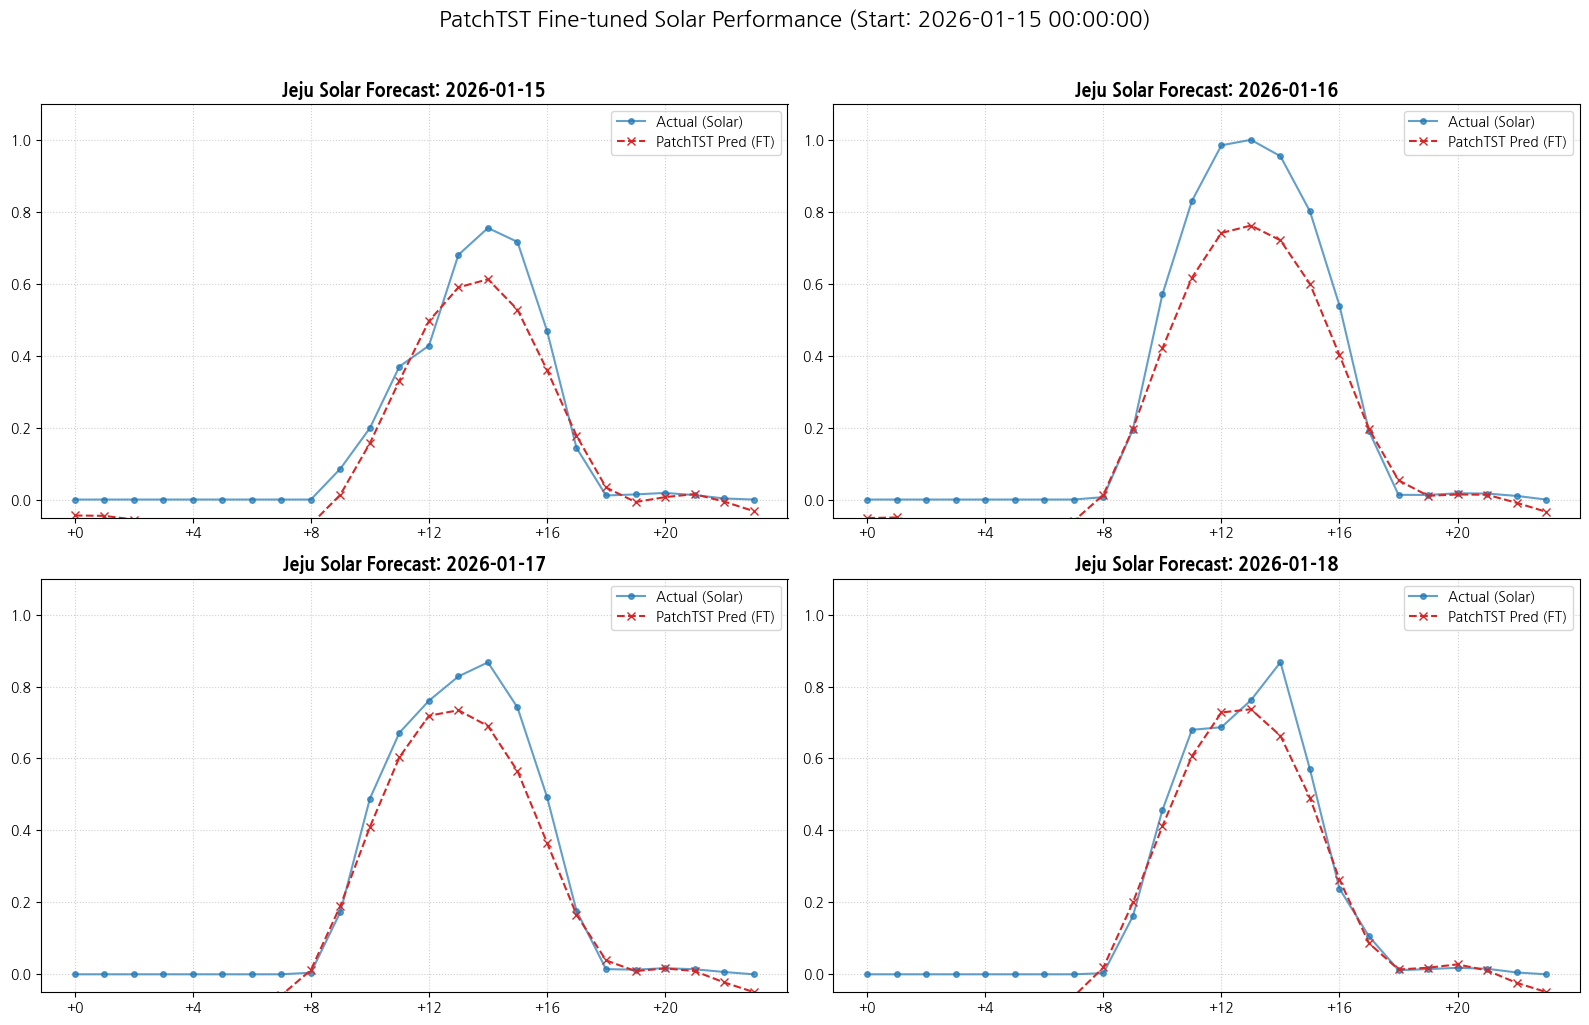

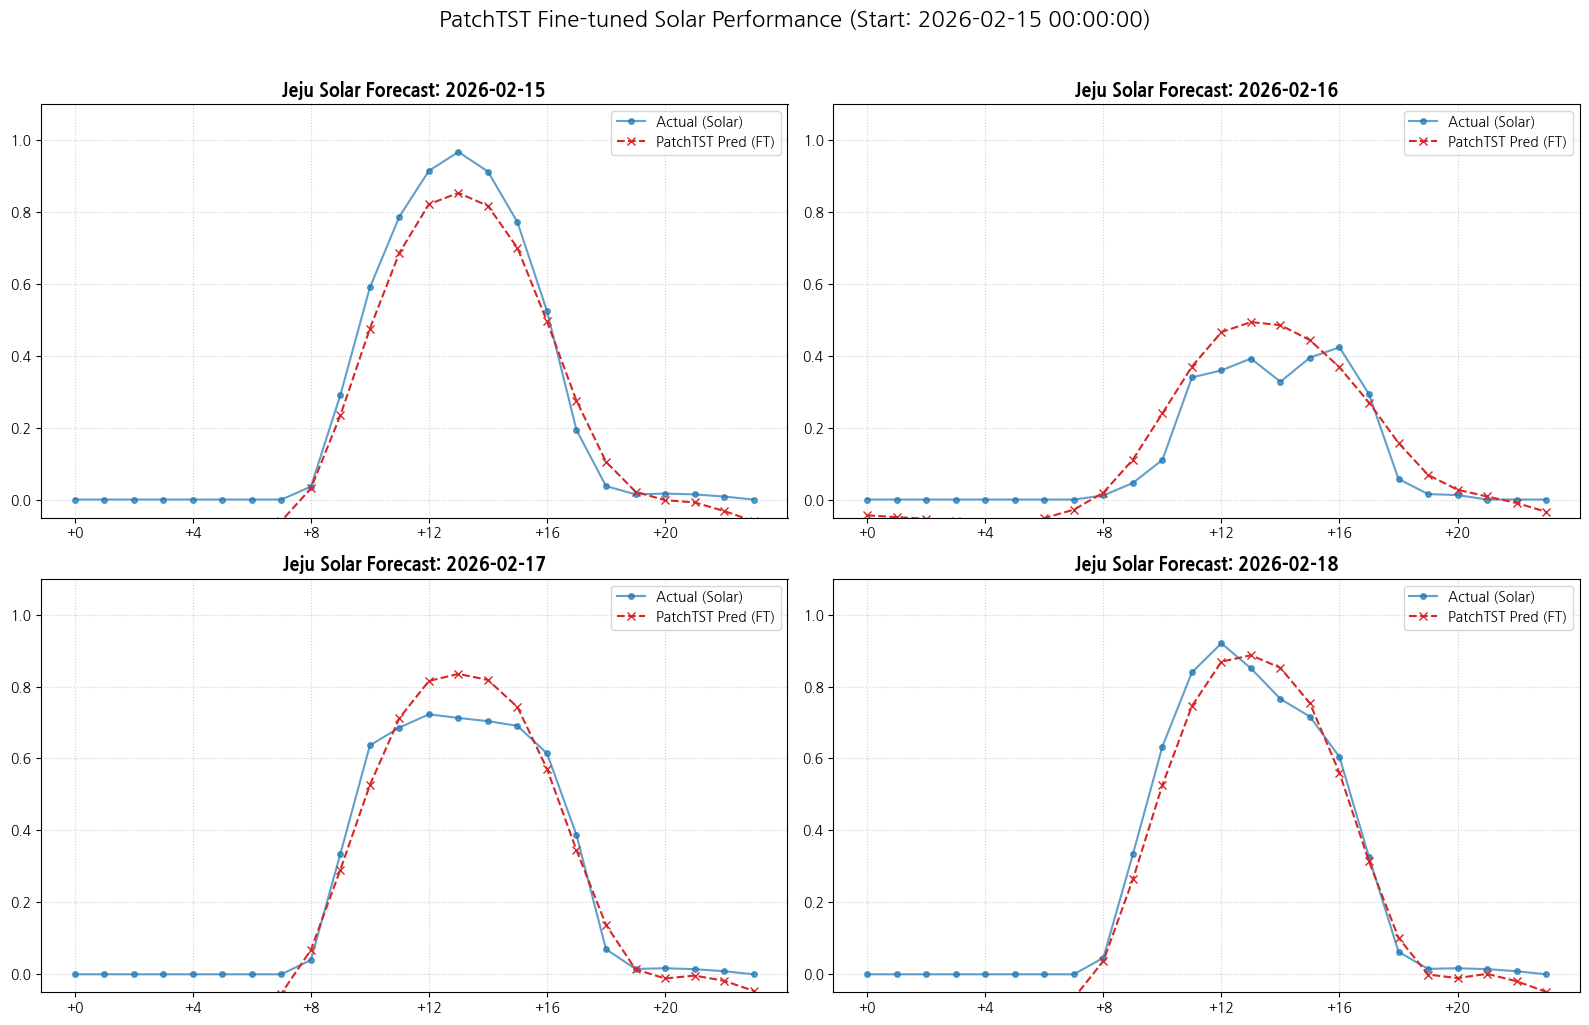

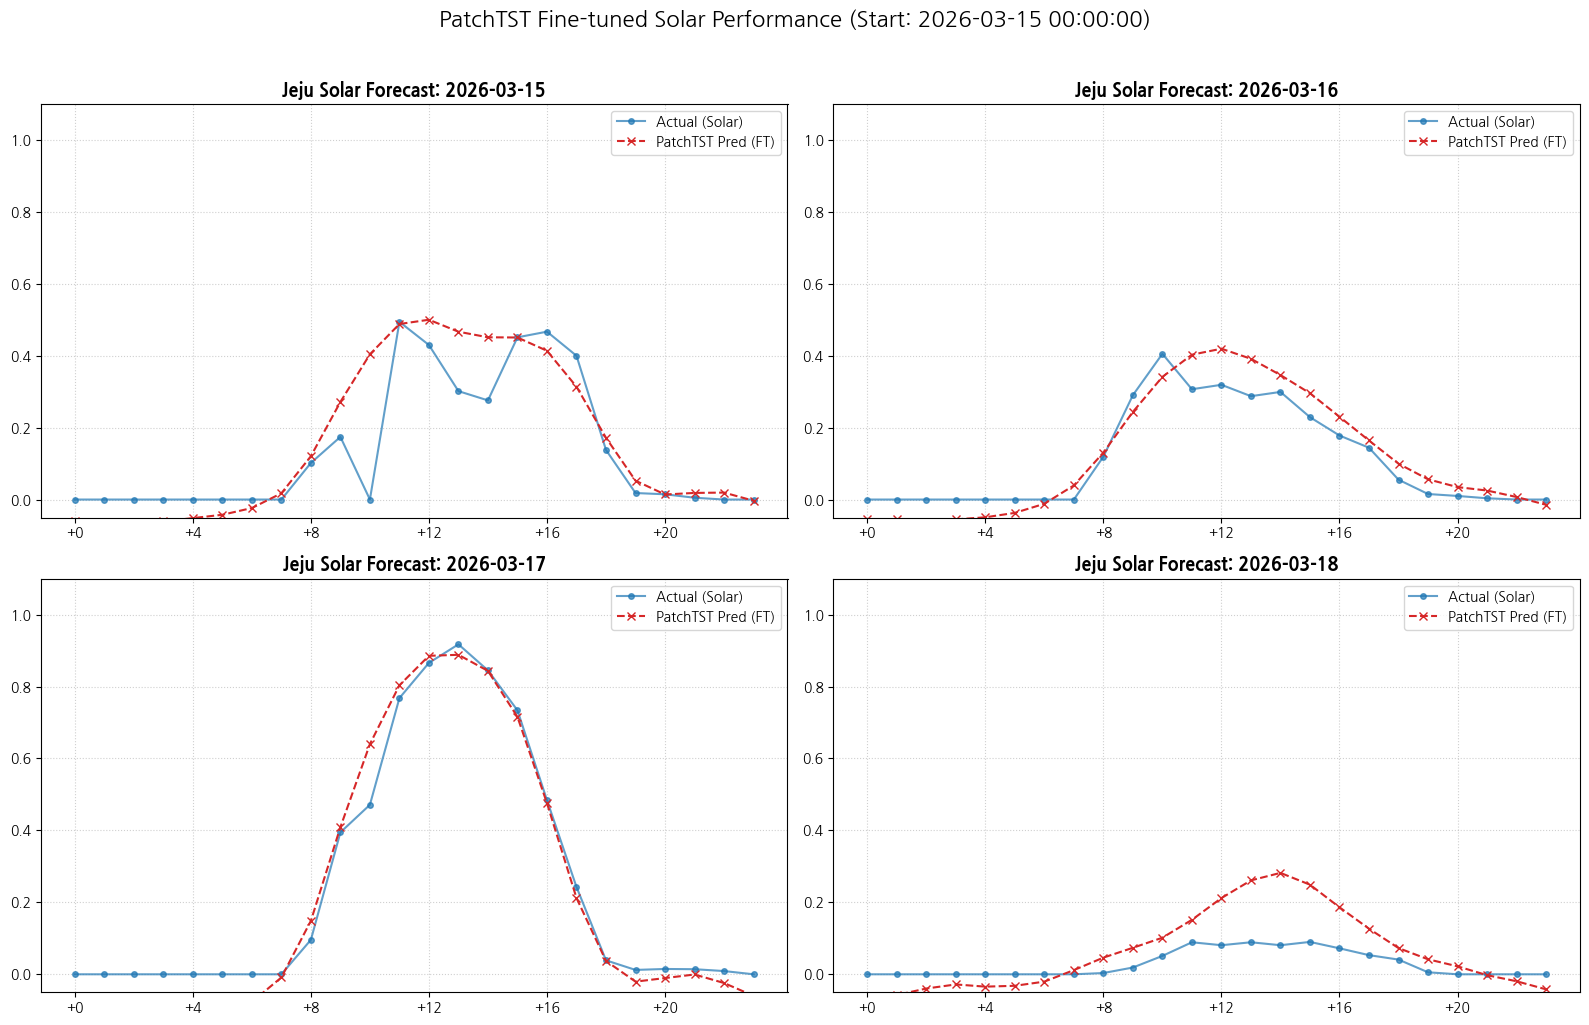

In [ ]:
# ==========================================
# Fine-tuned Solar 모델 평가
# ==========================================

best_model = PatchTST_Weather_Model(
    num_features=input_size,
    seq_len=SEQ_LEN,
    pred_len=PRED_LEN,
    patch_len=PATCH_LEN,
    stride=STRIDE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(DEVICE)

weights_path = '/content/best_patchtst_solar_model_ft.pth'
best_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
best_model.eval()
print(f"✅ {weights_path} 로드 완료!")

# Test Dataset (26년 1월~ 데이터)
test_df_solar = df.loc['2026-01-01':].copy()
test_df_solar[future_features] = scaler_solar.transform(test_df_solar[future_features])

test_ds_solar = PatchTSTDataset(
    test_df_solar[features].values,
    SEQ_LEN,
    PRED_LEN,
    future_cov_idx,
    target_idx
)
print(f"✅ Test Dataset: {len(test_ds_solar)}개 샘플 (기간: {test_df_solar.index[0]} ~ {test_df_solar.index[-1]})")

# ==========================================
# 시각화 함수
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

def plot_solar_forecast(start_date_str):
    try:
        target_start_loc = test_df_solar.index.get_loc(start_date_str)
    except KeyError:
        print(f"❌ '{start_date_str}'는 테스트 데이터 기간에 없습니다.")
        print(f"   사용 가능 기간: {test_df_solar.index[SEQ_LEN]} ~ {test_df_solar.index[-PRED_LEN]}")
        return

    base_idx = target_start_loc - SEQ_LEN
    if base_idx < 0 or base_idx + 72 >= len(test_ds_solar):
        print("❌ 시퀀스 데이터가 부족하여 그래프를 그릴 수 없습니다.")
        return

    indices = [base_idx, base_idx + 24, base_idx + 48, base_idx + 72]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = test_ds_solar[idx]
            batch_sample = {k: v.unsqueeze(0).to(DEVICE) for k, v in sample.items()}
            pred_y = best_model(batch_sample)

            actual = sample['future_y'].numpy()
            predicted = pred_y.squeeze().cpu().numpy()

            current_date = test_df_solar.index[target_start_loc + (i * 24)].strftime('%Y-%m-%d')

            ax = axes[i]
            ax.plot(actual, label='Actual (Solar)', marker='o', markersize=4, color='#1f77b4', alpha=0.7)
            ax.plot(predicted, label='PatchTST Pred (FT)', marker='x', linestyle='--', color='#d62728', linewidth=1.5)
            ax.set_title(f"Jeju Solar Forecast: {current_date}", fontsize=13, fontweight='bold')
            ax.set_ylim(-0.05, 1.1)
            ax.set_xticks(range(0, 24, 4))
            ax.set_xticklabels([f"+{h}" for h in range(0, 24, 4)])
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"PatchTST Fine-tuned Solar Performance (Start: {start_date_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 실행
plot_solar_forecast('2026-01-15 00:00:00')
plot_solar_forecast('2026-02-15 00:00:00')
plot_solar_forecast('2026-03-15 00:00:00')

In [ ]:
joblib.dump(scaler_solar, 'robust_scaler_solar_claude.pkl')

['robust_scaler_solar_claude.pkl']

In [ ]:
import joblib

# 1. 스케일러 각각 저장 (학습할 때 사용한 스케일러 객체를 각각 저장합니다)
joblib.dump(scaler_solar, 'robust_scaler_solar.pkl')
joblib.dump(scaler_wind, 'robust_scaler_wind.pkl')

# 2. 통합 메타데이터 저장 (태양광/풍력 피처 리스트 모두 포함)
metadata = {
    # 💡 [핵심 수정] 태양광 피처 정보 이름표를 앱과 똑같이 맞춰줍니다!
    'features_solar': features,
    'future_features_solar': future_features,

    # 풍력 피처 정보 (이 부분은 원래 완벽했습니다!)
    'features_wind': features_wind,
    'future_features_wind': future_features_wind,

    # 공통 정보
    'SEQ_LEN': SEQ_LEN,
    'PRED_LEN': PRED_LEN
}
joblib.dump(metadata, 'model_metadata.pkl')

print("✅ Streamlit 배포용 파일(스케일러 2개, 통합 메타데이터) 저장 완료!")

In [ ]:
# 2. 통합 메타데이터 저장 (태양광/풍력 피처 리스트 모두 포함)
features = [
    #'temp_c', 'wind_spd', 'humidity', 'rainfall',
    'solar_rad', 'total_cloud', 'midlow_cloud',
    'solar_damping',
    #'wd_sin', 'wd_cos',
    'Hour_sin', 'Hour_cos',
    #'Year_sin', 'Year_cos', #'Extra_Radiation',
    #'Solar_Elevation_scaled',
    'Solar_Utilization'
]

# 미래 예보로 사용할 피처 (Target인 Utilization 2개 제외하여 데이터 누수 방지)
future_features = [col for col in features if 'Utilization' not in col]


features_wind = [
    'wind_spd', 'wind_spd_sq', 'wind_spd_cu', 'wd_sin', 'wd_cos',
    'Hour_sin', 'Hour_cos', 'Year_sin', 'Year_cos', 'wind_zone',
    'Wind_Utilization'
]

future_features_wind = [col for col in features_wind if 'Utilization' not in col]

metadata = {
    'features_solar': features,
    'future_features_solar': future_features,
    'features_wind': features_wind,
    'future_features_wind': future_features_wind,
    'SEQ_LEN_SOLAR': 336,
    'SEQ_LEN_WIND': 72,
    'PRED_LEN': 24
}
joblib.dump(metadata, 'model_metadata.pkl')

['model_metadata.pkl']